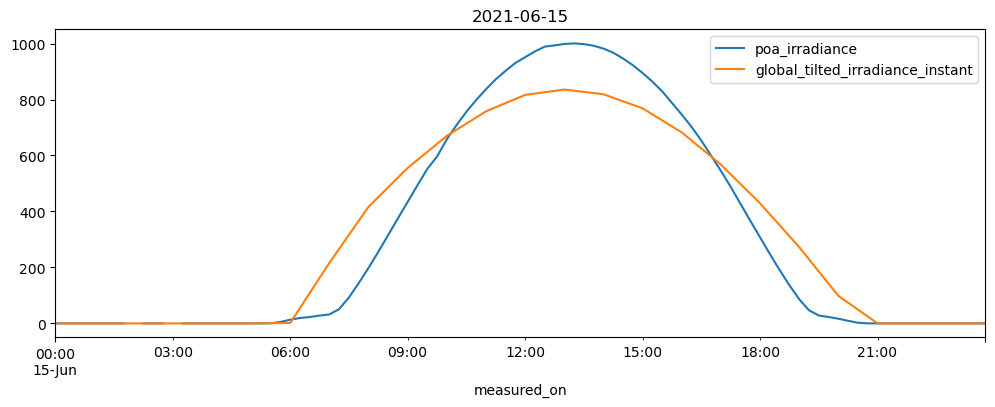

                                  poa_irradiance  \
poa_irradiance                          1.000000   
global_tilted_irradiance_instant        0.858128   

                                  global_tilted_irradiance_instant  
poa_irradiance                                            0.858128  
global_tilted_irradiance_instant                          1.000000  


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Fix notebook working directory
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

base = pd.read_parquet("data/processed/pretraining/farm2107_pretrain_base.parquet")

# Pick a clear-ish summer day
day = "2021-06-15"
mask = base["measured_on"].dt.date == pd.to_datetime(day).date()
df_day = base[mask].set_index("measured_on")

df_day[["poa_irradiance", "global_tilted_irradiance_instant"]].plot(figsize=(12,4))
plt.title(day)
plt.show()

print(
    base[["poa_irradiance", "global_tilted_irradiance_instant"]]
    .dropna()
    .corr()
)

### Comparison, Regression, Error Metrics, Bias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import seaborn as sns

# -------------------------------------------------------------
# PREP
# -------------------------------------------------------------
df = base.copy()  # Use 'base' from the first cell
df = df.dropna(subset=["poa_irradiance", "global_tilted_irradiance_instant"])

# Choose a clean day with full irradiance curve
day = "2021-06-15"
df_day = df[df["measured_on"].dt.date == pd.to_datetime(day).date()]

# -------------------------------------------------------------
# 1. CLEAN DAY COMPARISON PLOT
# -------------------------------------------------------------
plt.figure(figsize=(12,6))
plt.plot(df_day["measured_on"], df_day["poa_irradiance"], label="POA (Measured)", linewidth=2)
plt.plot(df_day["measured_on"], df_day["global_tilted_irradiance_instant"], 
         label="GTI (Open-Meteo Modeled)", linewidth=2)

plt.title(f"Irradiance Comparison — {day}")
plt.xlabel("Time (Local)")
plt.ylabel("Irradiance [W/m²]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# -------------------------------------------------------------
# 2. REGRESSION LINE (GTI → POA)
# -------------------------------------------------------------
plt.figure(figsize=(7,7))
sns.regplot(
    x=df["global_tilted_irradiance_instant"],
    y=df["poa_irradiance"],
    scatter_kws={"s": 5, "alpha": 0.3},
    line_kws={"color": "red"}
)

plt.title("Regression Fit: GTI (Modelled) → POA (Measured)")
plt.xlabel("Open-Meteo GTI [W/m²]")
plt.ylabel("Measured POA Irradiance [W/m²]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# -------------------------------------------------------------
# 3. MAE / RMSE BASELINE
# -------------------------------------------------------------
y_true = df["poa_irradiance"].values
y_pred = df["global_tilted_irradiance_instant"].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("====== MODEL → SENSOR IRRADIANCE ERROR ANALYSIS ======")
print(f"MAE  (W/m²): {mae:.2f}")
print(f"RMSE (W/m²): {rmse:.2f}")


# -------------------------------------------------------------
# 4. BIAS ANALYSIS
# -------------------------------------------------------------
df["irradiance_bias"] = df["global_tilted_irradiance_instant"] - df["poa_irradiance"]

plt.figure(figsize=(12,4))
plt.plot(df["measured_on"], df["irradiance_bias"], linewidth=0.7)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Bias Over Time (GTI - POA)")
plt.ylabel("W/m²")
plt.xlabel("Time")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n====== BIAS SUMMARY ======")
print(df["irradiance_bias"].describe())

NameError: name 'merged_df' is not defined